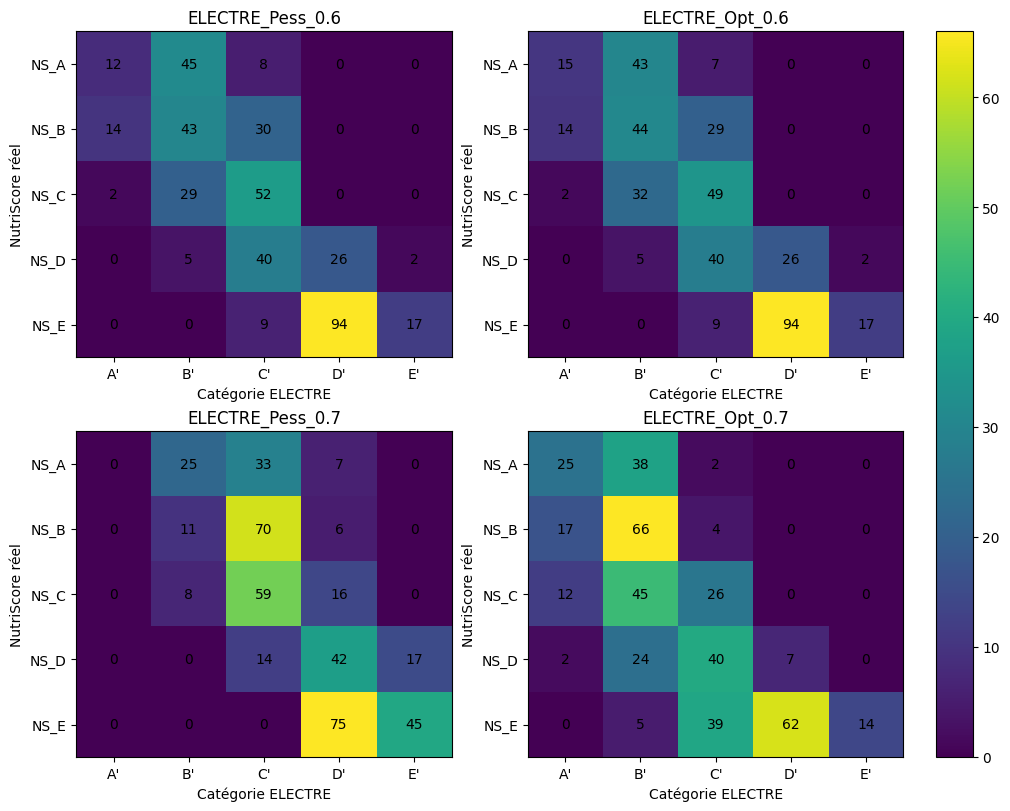

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from electre import ElectreTri

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assurez-vous que la classe ElectreTri est accessible 
from electre import ElectreTri 

# 1. Load Other Group's Data
# Using the filename you provided
file_path = 'food_database.xlsx' 

try:
    # Try reading as Excel
    df_other = pd.read_excel(file_path)
    print("Excel file loaded successfully.")
except:
    # Fallback to CSV if Excel fails
    print("Excel load failed, trying CSV...")
    df_other = pd.read_csv('food_database.xlsx - Products.csv')
    print("CSV file loaded successfully.")

# 2. Column Mapping (Crucial Step)
# Mapping the other group's column names to your French internal names
column_mapping = {
    'energy_100g': 'Energie_kJ',
    'sugars_100g': 'Sucres_g',
    'saturated_fat_100g': 'Graisses_Sat_g',
    'salt_100g': 'Sel_g',
    'fiber_100g': 'Fibres_g',
    'proteins_100g': 'Proteines_g',         
    'fvl_percent': 'Fruits_Legumes_Pct',      
    'green_score_value': 'GreenScore_Score',
    'nutri_score_label': 'NutriScore_Lettre'
}

df_other = df_other.rename(columns=column_mapping)

# 3. Data Cleaning
criteria = [
    "Energie_kJ", "Sucres_g", "Graisses_Sat_g", "Sel_g",
    "Proteines_g", "Fibres_g", "Fruits_Legumes_Pct", "GreenScore_Score"
]

for c in criteria:
    if c in df_other.columns:
        df_other[c] = df_other[c].fillna(0)
    else:
        print(f"Warning: Column {c} not found in dataset.")

# Filter for valid Nutri-Score labels only (A-E)
valid_scores = ['A', 'B', 'C', 'D', 'E']
if 'NutriScore_Lettre' in df_other.columns:
    df_other['NutriScore_Lettre'] = df_other['NutriScore_Lettre'].astype(str).str.upper()
    df_other = df_other[df_other['NutriScore_Lettre'].isin(valid_scores)]
    print(f"Valid products for comparison: {len(df_other)}")

Excel file loaded successfully.
Valid products for comparison: 353


In [17]:
# 4. Model Configuration
# Directions: -1 (minimize), 1 (maximize)
directions = {
    "Energie_kJ": -1,
    "Sucres_g": -1,
    "Graisses_Sat_g": -1,
    "Sel_g": -1,
    "Proteines_g": 1,
    "Fibres_g": 1,
    "Fruits_Legumes_Pct": 1,
    "GreenScore_Score": 1
}

# Equal weights
weights = {c: 1 / len(criteria) for c in criteria}

# Categories
category_labels = ["E", "D", "C", "B", "A"]

# Initialize Model with both lambdas (0.6 and 0.7)
model = ElectreTri(
    criteria=criteria, 
    directions=directions, 
    weights=weights, 
    category_labels=category_labels,
    lambdas=(0.6, 0.7) # Comparing both thresholds
)

# 5. Apply Model and Get Confusion Matrices
# This method (from your code) builds profiles, assigns classes, and computes confusion matrices
df_results, confusions = model.apply_and_confusion(df_other, target_col="NutriScore_Lettre")

print("Model applied successfully for lambda=0.6 and lambda=0.7")

Model applied successfully for lambda=0.6 and lambda=0.7


Displaying Confusion Matrices for Other Group Comparison:


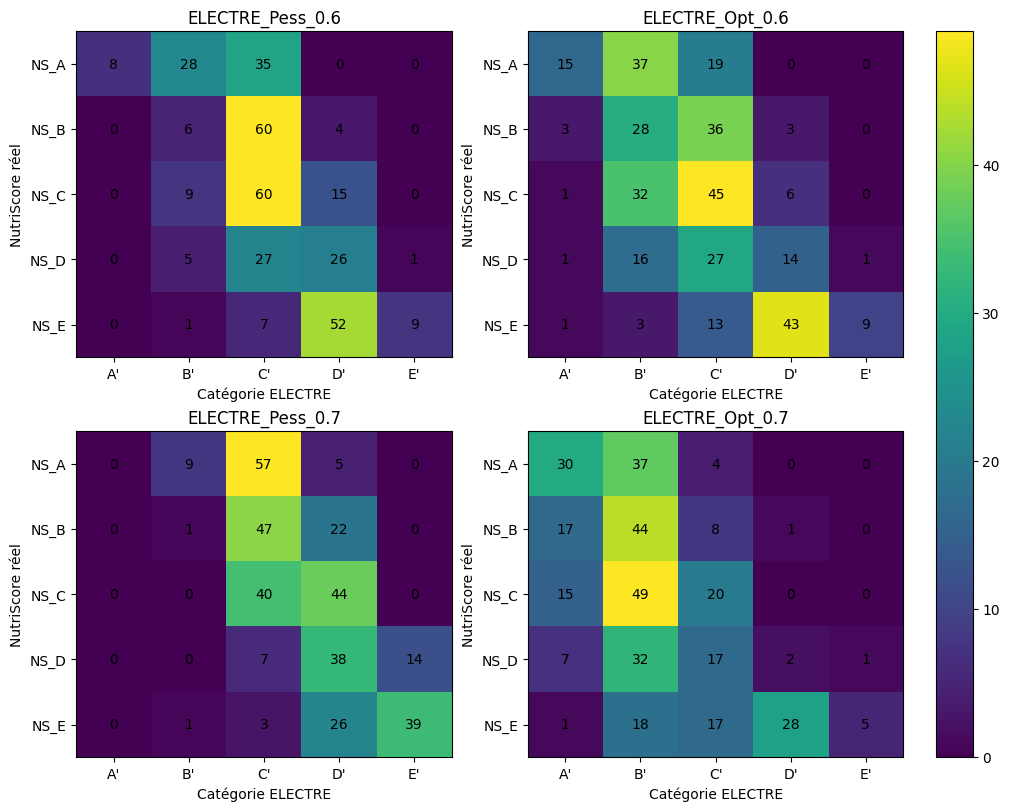

In [ ]:
# visualization
# Using the static method from your class to plot all matrices
print("Displaying Confusion Matrices for Other Group Comparison:")
ElectreTri.plot_confusion_matrices(confusions)

